# XGBoost Model for Delinquency Prediction

Uses the **top N selected features** from the comprehensive feature selection pipeline.

- Train / Validation / Test split (60/20/20)
- XGBoost binary classifier with early stopping
- Handles class imbalance with `scale_pos_weight`
- No feature scaling required for tree-based models
- Records training time, scoring time, ROC-AUC, and Average Precision

In [10]:
import sys
import pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    precision_recall_curve, average_precision_score, roc_curve,
)
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

from scripts.model_data import load_and_split

## 1. Load Data & Selected Features

In [11]:
# ── Configuration ────────────────────────────────────────────────
N_FEATURES = 100  # ← change this to use a different number of top-ranked features
FEATURES_FILE = "filtered_features_consensus_ordered.csv"

# Load features and perform 60/20/20 stratified split
X_train, X_val, X_test, y_train, y_val, y_test, available_features, features_df = \
    load_and_split(n_features=N_FEATURES, features_filename=FEATURES_FILE)

print(f'Features used:  {len(available_features)}')
print(f'Train:          {X_train.shape}  |  positives: {y_train.sum()} ({100*y_train.mean():.1f}%)')
print(f'Validation:     {X_val.shape}  |  positives: {y_val.sum()} ({100*y_val.mean():.1f}%)')
print(f'Test:           {X_test.shape}  |  positives: {y_test.sum()} ({100*y_test.mean():.1f}%)')

Features  : 100 (top-100)
Samples   : 10754  |  DQ rate: 8.18%
Train     : 6452  (8.18% positive)
Val       : 2151  (8.18% positive)
Test      : 2151  (8.18% positive)
Features used:  100
Train:          (6452, 100)  |  positives: 528 (8.2%)
Validation:     (2151, 100)  |  positives: 176 (8.2%)
Test:           (2151, 100)  |  positives: 176 (8.2%)


## 2. Prepare DMatrix Objects

XGBoost uses its own `DMatrix` format. No scaling is needed for tree-based models.

In [12]:
# Compute scale_pos_weight to handle class imbalance
n_neg = int(np.sum(y_train == 0))
n_pos = int(np.sum(y_train == 1))
scale_pos_weight = n_neg / n_pos
print(f'scale_pos_weight: {scale_pos_weight:.2f}  (neg={n_neg}, pos={n_pos})')

# Build DMatrix objects (XGBoost native format)
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=list(available_features))
dval   = xgb.DMatrix(X_val,   label=y_val,   feature_names=list(available_features))
dtest  = xgb.DMatrix(X_test,  label=y_test,  feature_names=list(available_features))

print('\nDMatrix objects created successfully.')

scale_pos_weight: 11.22  (neg=5924, pos=528)

DMatrix objects created successfully.


## 3. Hyperparameter Tuning with Optuna

Use **Optuna** (TPE sampler) to minimise overfitting and maximise validation AUC.  
The search targets the key regularisation knobs: tree depth, leaf weight, gamma, L1/L2, and sampling rates.

In [13]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_TRIALS      = 80    # increase for a more thorough search
EARLY_STOPPING = 30
NUM_BOOST_ROUND = 1000

def objective(trial):
    p = {
        'objective':         'binary:logistic',
        'eval_metric':       'auc',
        'scale_pos_weight':  scale_pos_weight,
        'seed':              42,
        'verbosity':         0,
        # --- tree complexity ---
        'max_depth':         trial.suggest_int('max_depth', 2, 6),
        'min_child_weight':  trial.suggest_int('min_child_weight', 5, 50),
        'gamma':             trial.suggest_float('gamma', 0.0, 5.0),
        # --- regularisation ---
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 10.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1.0, 20.0),
        # --- stochastic sampling ---
        'eta':               trial.suggest_float('eta', 0.01, 0.1, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 0.9)
    }

    pruning_cb = optuna.integration.XGBoostPruningCallback(trial, 'val-auc')

    bst = xgb.train(
        p,
        dtrain,
        num_boost_round=NUM_BOOST_ROUND,
        evals=[(dtrain, 'train'), (dval, 'val')],
        early_stopping_rounds=EARLY_STOPPING,
        verbose_eval=False,
        callbacks=[pruning_cb],
    )
    return bst.best_score   # maximise val AUC

sampler = optuna.samplers.TPESampler(seed=42)
pruner  = optuna.pruners.MedianPruner(n_warmup_steps=10)
study   = optuna.create_study(direction='maximize', sampler=sampler, pruner=pruner)

print(f'Running Optuna search ({N_TRIALS} trials) …')
t_tune = time.time()
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f'Search finished in {time.time()-t_tune:.1f}s')
print(f'\nBest val AUC : {study.best_value:.4f}')
print(f'Best params  :')
for k, v in study.best_params.items():
    print(f'  {k:<22} {v}')

Running Optuna search (80 trials) …


  0%|          | 0/80 [00:00<?, ?it/s]

Search finished in 8.8s

Best val AUC : 0.8019
Best params  :
  max_depth              4
  min_child_weight       15
  gamma                  2.3224816595124826
  reg_alpha              8.16755007065582
  reg_lambda             6.255697109863585
  eta                    0.09052651425979183
  subsample              0.659046505317891
  colsample_bytree       0.46118195877747536


## 4. Train Final Model with Best Hyperparameters

In [14]:
params = {
    'objective':        'binary:logistic',
    'eval_metric':      ['auc', 'aucpr'],
    'scale_pos_weight': scale_pos_weight,
    'seed':             42,
    'verbosity':        1,
    **study.best_params,
}

evals = [(dtrain, 'train'), (dval, 'val')]
evals_result = {}

print(f'Training final XGBoost with best params (top-{N_FEATURES} features)…')
t0 = time.time()
booster = xgb.train(
    params,
    dtrain,
    num_boost_round=NUM_BOOST_ROUND,
    evals=evals,
    early_stopping_rounds=EARLY_STOPPING,
    evals_result=evals_result,
    verbose_eval=100,
)
training_time = time.time() - t0

train_auc_base = evals_result['train']['auc'][booster.best_iteration]
val_auc_base   = evals_result['val']['auc'][booster.best_iteration]

print(f'\nTraining completed in {training_time:.2f}s')
print(f'Best iteration : {booster.best_iteration}')
print(f'Train AUC      : {train_auc_base:.4f}')
print(f'Best val AUC   : {val_auc_base:.4f}')


Training final XGBoost with best params (top-100 features)…
[0]	train-auc:0.76590	train-aucpr:0.20516	val-auc:0.69363	val-aucpr:0.16146
[52]	train-auc:0.92363	train-aucpr:0.50352	val-auc:0.79577	val-aucpr:0.30567

Training completed in 0.15s
Best iteration : 22
Train AUC      : 0.8775
Best val AUC   : 0.7876


In [15]:
# ── Evaluate Baseline Model on Test Set ──────────────────────────────────────
t0 = time.time()
y_prob_base = booster.predict(dtest)
scoring_time_base = time.time() - t0

roc_auc_base = roc_auc_score(y_test, y_prob_base)
ap_base = average_precision_score(y_test, y_prob_base)

print(f'Baseline XGBoost  –  Test Results')
print(f'  Train AUC         : {train_auc_base:.4f}')
print(f'  Val AUC           : {val_auc_base:.4f}')
print(f'  ROC-AUC (test)    : {roc_auc_base:.4f}')
print(f'  Average Precision : {ap_base:.4f}')
print(f'  Training time     : {training_time:.2f}s')
print(f'  Scoring time      : {scoring_time_base:.4f}s')

y_pred_base = (y_prob_base >= 0.5).astype(int)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_base))


Baseline XGBoost  –  Test Results
  Train AUC         : 0.8775
  Val AUC           : 0.7876
  ROC-AUC (test)    : 0.8092
  Average Precision : 0.2970
  Training time     : 0.15s
  Scoring time      : 0.0020s

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.81      0.88      1975
           1       0.23      0.64      0.34       176

    accuracy                           0.79      2151
   macro avg       0.60      0.72      0.61      2151
weighted avg       0.90      0.79      0.83      2151



## 5. SMOTE Oversampling

Apply **SMOTE** (Synthetic Minority Over-sampling Technique) to the training data, then re-run Optuna and train a new XGBoost model on the balanced set. Because the classes are balanced after resampling, `scale_pos_weight` is set to 1.

In [16]:
from imblearn.over_sampling import SMOTE

# ── Apply SMOTE ───────────────────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'SMOTE resampled   : {X_train_sm.shape}  |  positives: {y_train_sm.sum()} ({100*y_train_sm.mean():.1f}%)')

dtrain_sm = xgb.DMatrix(X_train_sm, label=y_train_sm, feature_names=list(available_features))

# ── Optuna search on SMOTE data ───────────────────────────────────────────────
def objective_sm(trial):
    p = {
        'objective':        'binary:logistic',
        'eval_metric':      'auc',
        'scale_pos_weight': 1,
        'seed':             42,
        'verbosity':        0,
        'max_depth':        trial.suggest_int('max_depth', 2, 6),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 50),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 10.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1.0, 20.0),
        'eta':              trial.suggest_float('eta', 0.01, 0.1, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.9),
    }
    pruning_cb = optuna.integration.XGBoostPruningCallback(trial, 'val-auc')
    bst = xgb.train(p, dtrain_sm, num_boost_round=NUM_BOOST_ROUND,
                    evals=[(dtrain_sm, 'train'), (dval, 'val')],
                    early_stopping_rounds=EARLY_STOPPING, verbose_eval=False,
                    callbacks=[pruning_cb])
    return bst.best_score

study_sm = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
print(f'Running Optuna (SMOTE) – {N_TRIALS} trials …')
t_tune = time.time()
study_sm.optimize(objective_sm, n_trials=N_TRIALS, show_progress_bar=True)
print(f'Done in {time.time()-t_tune:.1f}s  |  Best val AUC: {study_sm.best_value:.4f}')

# ── Train final SMOTE model ───────────────────────────────────────────────────
params_sm = {
    'objective':        'binary:logistic',
    'eval_metric':      ['auc', 'aucpr'],
    'scale_pos_weight': 1,
    'seed':             42,
    'verbosity':        0,
    **study_sm.best_params,
}
evals_result_sm = {}
t0 = time.time()
booster_sm = xgb.train(params_sm, dtrain_sm, num_boost_round=NUM_BOOST_ROUND,
                        evals=[(dtrain_sm, 'train'), (dval, 'val')],
                        early_stopping_rounds=EARLY_STOPPING, verbose_eval=False,
                        evals_result=evals_result_sm)
training_time_sm = time.time() - t0

train_auc_sm = evals_result_sm['train']['auc'][booster_sm.best_iteration]
val_auc_sm   = evals_result_sm['val']['auc'][booster_sm.best_iteration]

t0 = time.time()
y_prob_sm = booster_sm.predict(dtest)
scoring_time_sm = time.time() - t0

roc_auc_sm = roc_auc_score(y_test, y_prob_sm)
ap_sm = average_precision_score(y_test, y_prob_sm)

print(f'\nSMOTE XGBoost  –  Test Results')
print(f'  Train AUC         : {train_auc_sm:.4f}')
print(f'  Val AUC           : {val_auc_sm:.4f}')
print(f'  ROC-AUC (test)    : {roc_auc_sm:.4f}')
print(f'  Average Precision : {ap_sm:.4f}')
print(f'  Training time     : {training_time_sm:.2f}s')
print(f'  Scoring time      : {scoring_time_sm:.4f}s')

y_pred_sm = (y_prob_sm >= 0.5).astype(int)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_sm))


SMOTE resampled   : (11848, 100)  |  positives: 5924 (50.0%)
Running Optuna (SMOTE) – 80 trials …


  0%|          | 0/80 [00:00<?, ?it/s]

Done in 36.1s  |  Best val AUC: 0.7654

SMOTE XGBoost  –  Test Results
  Train AUC         : 0.9869
  Val AUC           : 0.7456
  ROC-AUC (test)    : 0.7735
  Average Precision : 0.2320
  Training time     : 0.51s
  Scoring time      : 0.0020s

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      1975
           1       0.28      0.20      0.24       176

    accuracy                           0.89      2151
   macro avg       0.60      0.58      0.59      2151
weighted avg       0.88      0.89      0.88      2151



## 6. ADASYN Oversampling

Apply **ADASYN** (Adaptive Synthetic Sampling). Unlike SMOTE, ADASYN generates more synthetic samples for minority-class points that are harder to classify (those near the decision boundary), producing a more adaptive resampled distribution.

In [17]:
from imblearn.over_sampling import ADASYN

# ── Apply ADASYN ──────────────────────────────────────────────────────────────
adasyn = ADASYN(random_state=42)
X_train_ad, y_train_ad = adasyn.fit_resample(X_train, y_train)
print(f'ADASYN resampled  : {X_train_ad.shape}  |  positives: {y_train_ad.sum()} ({100*y_train_ad.mean():.1f}%)')

dtrain_ad = xgb.DMatrix(X_train_ad, label=y_train_ad, feature_names=list(available_features))

# ── Optuna search on ADASYN data ──────────────────────────────────────────────
def objective_ad(trial):
    p = {
        'objective':        'binary:logistic',
        'eval_metric':      'auc',
        'scale_pos_weight': 1,
        'seed':             42,
        'verbosity':        0,
        'max_depth':        trial.suggest_int('max_depth', 2, 6),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 50),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 10.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1.0, 20.0),
        'eta':              trial.suggest_float('eta', 0.01, 0.1, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.9),
    }
    pruning_cb = optuna.integration.XGBoostPruningCallback(trial, 'val-auc')
    bst = xgb.train(p, dtrain_ad, num_boost_round=NUM_BOOST_ROUND,
                    evals=[(dtrain_ad, 'train'), (dval, 'val')],
                    early_stopping_rounds=EARLY_STOPPING, verbose_eval=False,
                    callbacks=[pruning_cb])
    return bst.best_score

study_ad = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
)
print(f'Running Optuna (ADASYN) – {N_TRIALS} trials …')
t_tune = time.time()
study_ad.optimize(objective_ad, n_trials=N_TRIALS, show_progress_bar=True)
print(f'Done in {time.time()-t_tune:.1f}s  |  Best val AUC: {study_ad.best_value:.4f}')

# ── Train final ADASYN model ──────────────────────────────────────────────────
params_ad = {
    'objective':        'binary:logistic',
    'eval_metric':      ['auc', 'aucpr'],
    'scale_pos_weight': 1,
    'seed':             42,
    'verbosity':        0,
    **study_ad.best_params,
}
evals_result_ad = {}
t0 = time.time()
booster_ad = xgb.train(params_ad, dtrain_ad, num_boost_round=NUM_BOOST_ROUND,
                        evals=[(dtrain_ad, 'train'), (dval, 'val')],
                        early_stopping_rounds=EARLY_STOPPING, verbose_eval=False,
                        evals_result=evals_result_ad)
training_time_ad = time.time() - t0

train_auc_ad = evals_result_ad['train']['auc'][booster_ad.best_iteration]
val_auc_ad   = evals_result_ad['val']['auc'][booster_ad.best_iteration]

t0 = time.time()
y_prob_ad = booster_ad.predict(dtest)
scoring_time_ad = time.time() - t0

roc_auc_ad = roc_auc_score(y_test, y_prob_ad)
ap_ad = average_precision_score(y_test, y_prob_ad)

print(f'\nADASYN XGBoost  –  Test Results')
print(f'  Train AUC         : {train_auc_ad:.4f}')
print(f'  Val AUC           : {val_auc_ad:.4f}')
print(f'  ROC-AUC (test)    : {roc_auc_ad:.4f}')
print(f'  Average Precision : {ap_ad:.4f}')
print(f'  Training time     : {training_time_ad:.2f}s')
print(f'  Scoring time      : {scoring_time_ad:.4f}s')

y_pred_ad = (y_prob_ad >= 0.5).astype(int)
print('\nClassification Report:')
print(classification_report(y_test, y_pred_ad))


ADASYN resampled  : (11871, 100)  |  positives: 5947 (50.1%)
Running Optuna (ADASYN) – 80 trials …


  0%|          | 0/80 [00:00<?, ?it/s]

Done in 30.3s  |  Best val AUC: 0.7586

ADASYN XGBoost  –  Test Results
  Train AUC         : 0.9815
  Val AUC           : 0.7382
  ROC-AUC (test)    : 0.7784
  Average Precision : 0.2235
  Training time     : 0.37s
  Scoring time      : 0.0020s

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.94      0.93      1975
           1       0.25      0.24      0.25       176

    accuracy                           0.88      2151
   macro avg       0.59      0.59      0.59      2151
weighted avg       0.88      0.88      0.88      2151



## 7. Model Comparison

Compare **ROC-AUC**, **Average Precision (PR-AUC)**, training time, and scoring time across all three strategies:

| Strategy | Imbalance Handling |
|---|---|
| **Baseline** | `scale_pos_weight` parameter in XGBoost |
| **SMOTE** | Synthetic minority oversampling before training |
| **ADASYN** | Adaptive synthetic sampling before training |

  Method  Train AUC  Val AUC  Test ROC-AUC  Avg Precision  Train Time (s)  Score Time (s)
Baseline   0.877487 0.787621      0.809200       0.296963        0.145059        0.002002
   SMOTE   0.986935 0.745583      0.773547       0.232018        0.505993        0.002004
  ADASYN   0.981499 0.738188      0.778389       0.223530        0.365126        0.002003


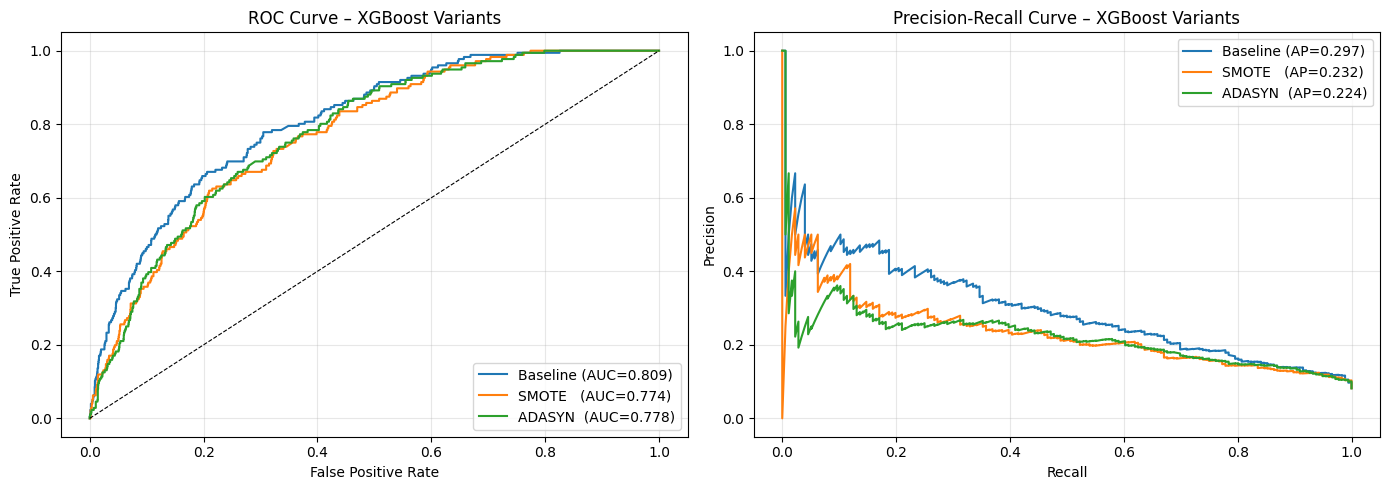

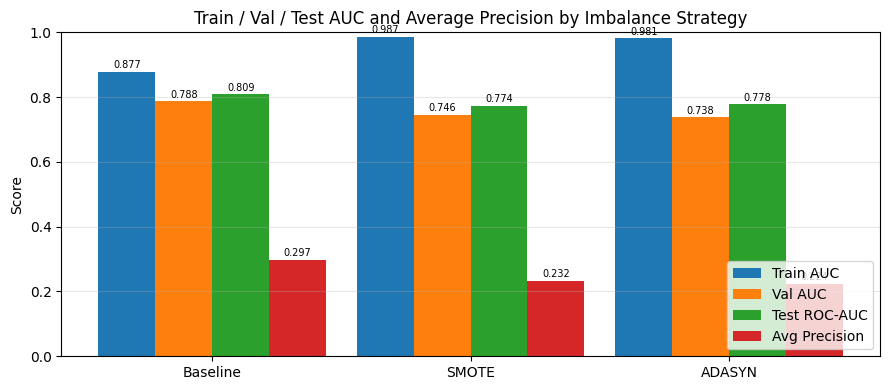

In [18]:
# ── Summary Table ─────────────────────────────────────────────────────────────
results = pd.DataFrame({
    'Method':          ['Baseline', 'SMOTE', 'ADASYN'],
    'Train AUC':       [train_auc_base, train_auc_sm, train_auc_ad],
    'Val AUC':         [val_auc_base,   val_auc_sm,   val_auc_ad],
    'Test ROC-AUC':    [roc_auc_base,   roc_auc_sm,   roc_auc_ad],
    'Avg Precision':   [ap_base,        ap_sm,         ap_ad],
    'Train Time (s)':  [training_time,  training_time_sm, training_time_ad],
    'Score Time (s)':  [scoring_time_base, scoring_time_sm, scoring_time_ad],
})
print(results.to_string(index=False))

# ── ROC + PR Curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

combos = [
    (y_prob_base, f'Baseline (AUC={roc_auc_base:.3f})', f'Baseline (AP={ap_base:.3f})', '#1f77b4'),
    (y_prob_sm,   f'SMOTE   (AUC={roc_auc_sm:.3f})',   f'SMOTE   (AP={ap_sm:.3f})',   '#ff7f0e'),
    (y_prob_ad,   f'ADASYN  (AUC={roc_auc_ad:.3f})',   f'ADASYN  (AP={ap_ad:.3f})',   '#2ca02c'),
]

for y_prob, roc_label, pr_label, color in combos:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=roc_label, color=color)

    prec, rec, _ = precision_recall_curve(y_test, y_prob)
    axes[1].plot(rec, prec, label=pr_label, color=color)

axes[0].plot([0, 1], [0, 1], 'k--', lw=0.8)
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='ROC Curve – XGBoost Variants')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

axes[1].set(xlabel='Recall', ylabel='Precision',
            title='Precision-Recall Curve – XGBoost Variants')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── AUC Comparison Bar Chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(3)
width = 0.22
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

bars = [
    ax.bar(x - width,     results['Train AUC'],    width, label='Train AUC',    color=colors[0]),
    ax.bar(x,             results['Val AUC'],       width, label='Val AUC',      color=colors[1]),
    ax.bar(x + width,     results['Test ROC-AUC'], width, label='Test ROC-AUC', color=colors[2]),
    ax.bar(x + 2*width,   results['Avg Precision'], width, label='Avg Precision', color=colors[3]),
]

ax.set_xticks(x + width / 2)
ax.set_xticklabels(results['Method'])
ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Train / Val / Test AUC and Average Precision by Imbalance Strategy')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)

for bar_group in bars:
    for bar in bar_group:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()
